# Unified Simulation Analysis: Mosquito Population Dynamics, Suitability, and Validation

This notebook analyses **LivingAgent (mosquitoes)** and **InertAgent (water tanks)** from large snapshot CSV files (GB scale) on a laptop with limited RAM. It produces:
- **Suitability maps** for adult mosquitoes and breeding sites – derived from KDE heatmaps and tank occupancy.
- **Validation** against real‑world occurrence data (GBIF / iNaturalist).
- **Life‑cycle validation** (stage durations, discrete‑time projection matrix λ_max).
- **Memory‑efficient** chunked processing and per‑tick spatial sampling.
- **Export of suitability rasters** (GeoTIFF) for further use in GIS.

## Configuration

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate, correlation_lags
from sklearn.neighbors import KernelDensity
from scipy.interpolate import RegularGridInterpolator
import rasterio
from rasterio.transform import from_origin
import os
import warnings
warnings.filterwarnings('ignore')

# ========== CONFIGURATION ==========
# --- EDIT THESE PATHS ---
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260426_150815.csv"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali"
# --- Occurrence data (GBIF / iNaturalist) ---
OCCURRENCE_FILE = "prepared_data/ethiopia_occurrence/merged_observations.csv"   # Set to a CSV or GeoJSON path, e.g., "occurrences.csv"
# -------------------------
TICKS_PER_DAY = 96
CHUNKSIZE = 100000               # rows per chunk for daily aggregation
MAX_SPATIAL_POINTS_PER_TICK = 100000   # max points to read for a single tick (memory safe)
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

# ---- Environment variables to analyse (add/remove as needed) ----
ENV_VARS = [
    ('t2m', 'Temperature', '°C', lambda x: x, False),      # CSV already Celsius
    ('tp', 'Precipitation', 'mm', lambda x: x * 1000, True),
]

# ---- Export settings ----
EXPORT_RASTERS = True          # set to False to skip GeoTIFF export
KDE_BANDWIDTH_DEG = 0.002      # bandwidth in degrees (~220 m at equator)
KDE_GRID_RES = 200             # number of cells along the longer axis

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ========== LOAD STUDY AREA BASEMAP ==========
study_area = None
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    if study_area.crs is None:
        study_area.crs = "EPSG:4326"
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {STUDY_AREA_FILE}")
    print(f"Bounds: {study_area.total_bounds}")
else:
    print(f"Study area file not found: {STUDY_AREA_FILE}. Spatial plots will be without basemap.")

# ========== LOAD OCCURRENCE DATA (if provided) ==========
occurrences = None
if OCCURRENCE_FILE and os.path.exists(OCCURRENCE_FILE):
    if OCCURRENCE_FILE.endswith('.shp') or OCCURRENCE_FILE.endswith('.geojson'):
        occurrences = gpd.read_file(OCCURRENCE_FILE).to_crs("EPSG:4326")
    else:
        occ_df = pd.read_csv(OCCURRENCE_FILE, delimiter=",")
        if 'longitude' in occ_df.columns and 'latitude' in occ_df.columns:
            occurrences = gpd.GeoDataFrame(occ_df, geometry=gpd.points_from_xy(occ_df.longitude, occ_df.latitude), crs="EPSG:4326")
        else:
            print("Occurrence CSV must contain 'longitude' and 'latitude' columns.")
    if occurrences is not None:
        original_count = len(occurrences)
        # Clip occurrences to study area (if available)
        if study_area is not None:
            if occurrences.crs != study_area.crs:
                occurrences = occurrences.to_crs(study_area.crs)
            occurrences = gpd.sjoin(occurrences, study_area, how='inner', predicate='within')
            occurrences = occurrences.drop(columns='index_right')
            print(f"Clipped occurrence records from {original_count} to {len(occurrences)} (inside study area)")
        else:
            print(f"Loaded {original_count} occurrence records (no clipping – study area missing).")
else:
    print("No occurrence file provided – validation plots will be skipped.")

# ========== DEFINE COLUMNS & DTYPES ==========
living_base_cols = ['TickCount', 'Stage', 'X', 'Y', 'AgentID', 'Age', 'Energy', 'Gravid']
env_col_names = [v[0] for v in ENV_VARS]
living_columns = living_base_cols + env_col_names
inert_columns = ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']

living_dtypes = {
    'TickCount': 'int32',
    'Stage': 'category',
    'X': 'float32',
    'Y': 'float32',
    'AgentID': 'object',
    'Age': 'int16',
    'Energy': 'float32',
    'Gravid': 'int8'
}
for col in env_col_names:
    living_dtypes[col] = 'float32'

inert_dtypes = {
    'TickCount': 'int32',
    'X': 'float32',
    'Y': 'float32',
    'EggCount': 'int32',
    'LarvaCount': 'int32',
    'waterVolume': 'float32',
    'AgentID': 'object'
}

print(f"Environment variables: {env_col_names}")
print("Configuration ready.")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/somali/somali.shp
Bounds: [39.09111796  3.40667    47.98824    11.09707999]
Clipped occurrence records from 72 to 30 (inside study area)
Environment variables: ['t2m', 'tp']
Configuration ready.


## 1. Memory‑Efficient Daily Aggregation

Processes the merged CSV in chunks and aggregates daily totals for populations and environmental means.

In [106]:
def incremental_aggregation(filepath, living_cols, inert_cols, living_dtypes, inert_dtypes, 
                            env_vars, chunksize):
    from collections import defaultdict

    daily_adults = defaultdict(int)
    daily_larvae = defaultdict(int)
    daily_pupae = defaultdict(int)
    daily_env_sum = {col: defaultdict(float) for col, _, _, _, _ in env_vars}
    daily_env_cnt = {col: defaultdict(int) for col, _, _, _, _ in env_vars}
    daily_tank_count = defaultdict(int)
    daily_water_sum = defaultdict(float)
    daily_water_cnt = defaultdict(int)
    daily_eggs_sum = defaultdict(int)
    daily_larva_sum = defaultdict(int)

    min_tick = None
    max_tick = None
    print("Starting chunked processing...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)

    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"Processing chunk {i}...")
        tick_min = chunk['TickCount'].min()
        tick_max = chunk['TickCount'].max()
        if min_tick is None or tick_min < min_tick:
            min_tick = tick_min
        if max_tick is None or tick_max > max_tick:
            max_tick = tick_max

        # ---- Living agents ----
        living_mask = chunk['AgentType'] == 'LivingAgent'
        living_chunk = chunk.loc[living_mask, living_cols].copy()
        if not living_chunk.empty:
            living_chunk = living_chunk.astype(living_dtypes)
            living_chunk['Day'] = (living_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in living_chunk.groupby('Day'):
                # Count stages
                adults = (grp['Stage'] == 'ADULT').sum()
                larvae = (grp['Stage'] == 'LARVA').sum()
                pupae = (grp['Stage'] == 'PUPA').sum()
                daily_adults[day] += adults
                daily_larvae[day] += larvae
                daily_pupae[day] += pupae

                # Environment variables (mean)
                for col, _, _, _, _ in env_vars:
                    if col in grp.columns:
                        daily_env_sum[col][day] += grp[col].sum()
                        daily_env_cnt[col][day] += len(grp)

        # ---- Inert agents ----
        inert_mask = chunk['AgentType'] == 'InertAgent'
        inert_chunk = chunk.loc[inert_mask, inert_cols].copy()
        if not inert_chunk.empty:
            inert_chunk = inert_chunk.astype(inert_dtypes)
            inert_chunk['Day'] = (inert_chunk['TickCount'] // TICKS_PER_DAY).astype('int32')
            for day, grp in inert_chunk.groupby('Day'):
                daily_tank_count[day] += grp['AgentID'].nunique()
                daily_water_sum[day] += grp['waterVolume'].sum()
                daily_water_cnt[day] += len(grp)
                daily_eggs_sum[day] += grp['EggCount'].sum()
                daily_larva_sum[day] += grp['LarvaCount'].sum()

    all_days = sorted(set(daily_adults.keys()) | set(daily_larvae.keys()) |
                      set(daily_pupae.keys()) |
                      set().union(*[daily_env_sum[col].keys() for col in daily_env_sum]) |
                      set(daily_tank_count.keys()))

    # Build daily living DataFrame
    daily_living_df = pd.DataFrame({'Day': all_days})
    daily_living_df['AdultCount'] = [daily_adults.get(d, 0) for d in all_days]
    daily_living_df['LarvaCount'] = [daily_larvae.get(d, 0) for d in all_days]
    daily_living_df['PupaCount'] = [daily_pupae.get(d, 0) for d in all_days]

    for col, disp, unit, convert, is_precip in env_vars:
        mean_col = f'Mean{disp}'
        raw_mean = [daily_env_sum[col].get(d, 0) / max(1, daily_env_cnt[col].get(d, 1)) for d in all_days]
        daily_living_df[mean_col] = convert(pd.Series(raw_mean)).round(2 if not is_precip else 4)

    # Build daily inert DataFrame
    daily_inert_df = pd.DataFrame({'Day': all_days})
    daily_inert_df['TankCount'] = [daily_tank_count.get(d, 0) for d in all_days]
    daily_inert_df['MeanWaterVolume'] = [
        daily_water_sum.get(d, 0) / max(1, daily_water_cnt.get(d, 1)) for d in all_days
    ]
    daily_inert_df['TotalEggs'] = [daily_eggs_sum.get(d, 0) for d in all_days]
    daily_inert_df['TotalLarvae'] = [daily_larva_sum.get(d, 0) for d in all_days]

    print(f"Processed ticks {min_tick} to {max_tick}")
    print(f"Unique days found: {len(all_days)}")
    return daily_living_df, daily_inert_df

daily_living, daily_inert = incremental_aggregation(
    INPUT_FILE, living_columns, inert_columns, living_dtypes, inert_dtypes, 
    ENV_VARS, CHUNKSIZE
)
print("\nDaily Living summary head:")
print(daily_living.head())
print("\nDaily Inert summary head:")
print(daily_inert.head())

Starting chunked processing...
Processing chunk 0...
Processed ticks 100 to 400
Unique days found: 4

Daily Living summary head:
   Day  AdultCount  LarvaCount  PupaCount  MeanTemperature  MeanPrecipitation
0    1       29944       12335       7564            25.75          88.623001
1    2       29160       12244       7550            25.75          88.348396
2    3       28765       12167       7528            25.75          88.491302
3    4       28489       12081       7504            25.75          88.413300

Daily Inert summary head:
   Day  TankCount  MeanWaterVolume  TotalEggs  TotalLarvae
0    1      10000        65.247215     453269       385105
1    2      10000        65.247215     360423       477951
2    3      10000        65.247215     288690       549684
3    4      10000        65.247215     228901       609473


## 2. Population Dynamics & Lifecycle Validation

Plots population trends, estimates stage durations via cross‑correlation, and compares observed growth rates with the discrete projection matrix (Metzler model).

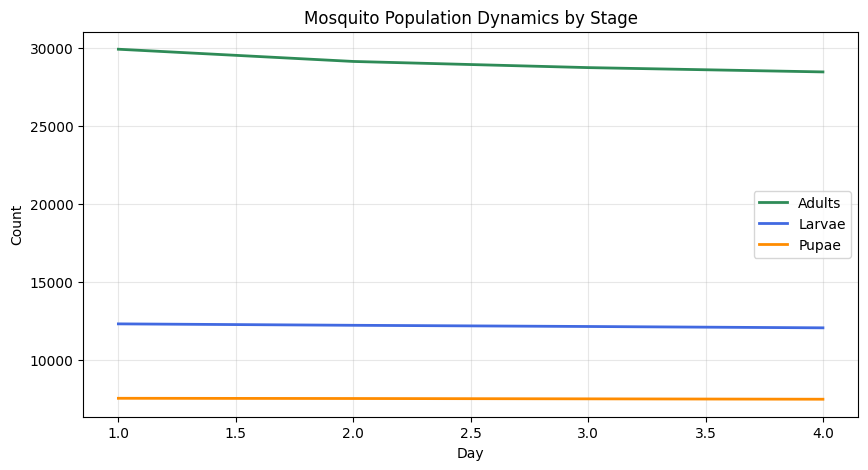

Could not estimate larval duration.
Could not estimate pupal duration.


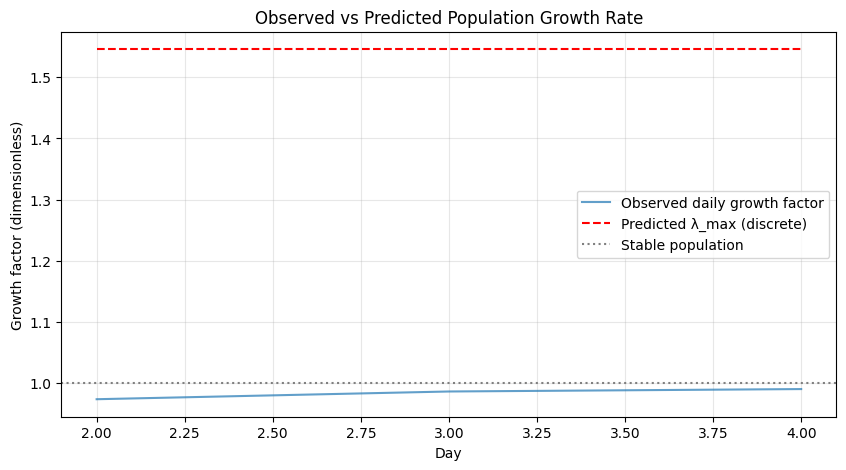

Average predicted λ_max: 1.546


In [107]:
# ---- Population dynamics plot ----
plt.figure(figsize=(10,5))
plt.plot(daily_living['Day'], daily_living['AdultCount'], label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['LarvaCount'], label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['PupaCount'], label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Mosquito Population Dynamics by Stage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/mosquito_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- Stage duration estimation (cross‑correlation) with improved method ----
def estimate_stage_duration(df, stage_from, stage_to, ticks_per_day=96, min_days=5, max_lag_days=20):
    df_sub = df[df['Day'] >= min_days].copy()
    if df_sub.empty:
        return None
    s1 = df_sub[f'{stage_from}Count'].values.astype(float)
    s2 = df_sub[f'{stage_to}Count'].values.astype(float)
    # Remove trailing zeros
    last = max(np.flatnonzero(s1)[-1] if np.any(s1) else 0,
               np.flatnonzero(s2)[-1] if np.any(s2) else 0)
    s1 = s1[:last+1]; s2 = s2[:last+1]
    s1 = s1 - np.mean(s1); s2 = s2 - np.mean(s2)
    lags = correlation_lags(len(s1), len(s2)) / ticks_per_day
    ccf = correlate(s1, s2, mode='full')
    # Only positive lags
    pos_mask = lags > 0
    if not np.any(pos_mask):
        return None
    ccf_pos = ccf[pos_mask]
    lags_pos = lags[pos_mask]
    # Quadratic peak refinement
    idx = np.argmax(ccf_pos)
    if 0 < idx < len(ccf_pos)-1:
        x = lags_pos[idx-1:idx+2]
        y = ccf_pos[idx-1:idx+2]
        A = np.vstack([x**2, x, np.ones_like(x)]).T
        coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        if coeffs[0] < 0:
            peak = -coeffs[1] / (2*coeffs[0])
            return abs(peak)
    return lags_pos[idx]

larval_days = estimate_stage_duration(daily_living, 'Larva', 'Pupa', TICKS_PER_DAY)
pupal_days = estimate_stage_duration(daily_living, 'Pupa', 'Adult', TICKS_PER_DAY)
if larval_days:
    print(f"Estimated larval duration: {larval_days:.2f} days")
else:
    print("Could not estimate larval duration.")
if pupal_days:
    print(f"Estimated pupal duration: {pupal_days:.2f} days")
else:
    print("Could not estimate pupal duration.")

# ---- Discrete projection matrix for growth rate validation ----
def discrete_lambda_max(T_C, livestock_density, params):
    term1 = params['fecundity_a'] * np.exp(params['fecundity_b'] * T_C)
    term2 = np.exp(params['fecundity_b'] * params['fecundity_Tmax'] - 
                   ((params['fecundity_Tmax'] - T_C) / params['fecundity_c'])**2)
    F = max(0, term1 - term2)
    dE = max(0, params['egg_dev_a']*T_C**2 + params['egg_dev_b']*T_C + params['egg_dev_c'])
    dL = max(0, params['larva_dev_a']*T_C**2 + params['larva_dev_b']*T_C + params['larva_dev_c'])
    dP = max(0, params['pupa_dev_a']*T_C**2 + params['pupa_dev_b']*T_C + params['pupa_dev_c'])
    muA = max(0, params['adult_mort_a']*T_C**2 + params['adult_mort_b']*T_C + params['adult_mort_c'])
    SE = params['egg_survival_amp'] * np.exp(-0.5 * ((T_C - params['egg_survival_mean'])/params['egg_survival_sigma'])**2)
    SL = params['larva_survival_amp'] * np.exp(-0.5 * ((T_C - params['larva_survival_mean'])/params['larva_survival_sigma'])**2)
    SP = params['pupa_survival_amp'] * np.exp(-0.5 * ((T_C - params['pupa_survival_mean'])/params['pupa_survival_sigma'])**2)
    K = 1 + np.log1p(max(0, livestock_density))
    A = np.array([
        [(1 - dE) * SE, 0, 0, F * K],
        [dE * SE, (1 - dL) * SL, 0, 0],
        [0, dL * SL, (1 - dP) * SP, 0],
        [0, 0, dP * SP, 1 - muA]
    ])
    eigvals = np.linalg.eigvals(A)
    return np.max(eigvals.real)

params = {
    'fecundity_a':0.378, 'fecundity_b':0.173, 'fecundity_Tmax':40.0, 'fecundity_c':2.97,
    'egg_dev_a':-0.0009, 'egg_dev_b':0.048, 'egg_dev_c':-0.345,
    'larva_dev_a':-0.0007, 'larva_dev_b':0.039, 'larva_dev_c':-0.32,
    'pupa_dev_a':-0.0005, 'pupa_dev_b':0.026, 'pupa_dev_c':-0.2,
    'egg_survival_amp':1.01, 'egg_survival_mean':24.5, 'egg_survival_sigma':4.8,
    'larva_survival_amp':0.95, 'larva_survival_mean':27.0, 'larva_survival_sigma':3.5,
    'pupa_survival_amp':0.93, 'pupa_survival_mean':26.8, 'pupa_survival_sigma':3.8,
    'adult_mort_a':-0.00065, 'adult_mort_b':0.0364, 'adult_mort_c':-0.4882
}
livestock_density = 0.5

temp_col = None
for col, disp, _, _, _ in ENV_VARS:
    if 'temp' in col.lower() or disp.lower() == 'temperature':
        temp_col = f'Mean{disp}'
        break

if temp_col is not None and temp_col in daily_living.columns:
    lambda_vals = [discrete_lambda_max(temp, livestock_density, params) for temp in daily_living[temp_col]]
    adult_counts = daily_living['AdultCount'].values
    observed_growth = adult_counts[1:] / (adult_counts[:-1] + 1e-6)
    days_obs = daily_living['Day'].values[1:]

    plt.figure(figsize=(10,5))
    plt.plot(days_obs, observed_growth, label='Observed daily growth factor', alpha=0.7)
    plt.plot(days_obs, lambda_vals[1:], label='Predicted λ_max (discrete)', linestyle='--', color='red')
    plt.axhline(1, color='gray', linestyle=':', label='Stable population')
    plt.xlabel('Day')
    plt.ylabel('Growth factor (dimensionless)')
    plt.title('Observed vs Predicted Population Growth Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/growth_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Average predicted λ_max: {np.mean(lambda_vals):.3f}")
else:
    print("No temperature column found – skipping Metzler validation.")

## 3. Water Tank Statistics

Plots mean water volume, mean egg count per tank, and mean larval count per tank over time.

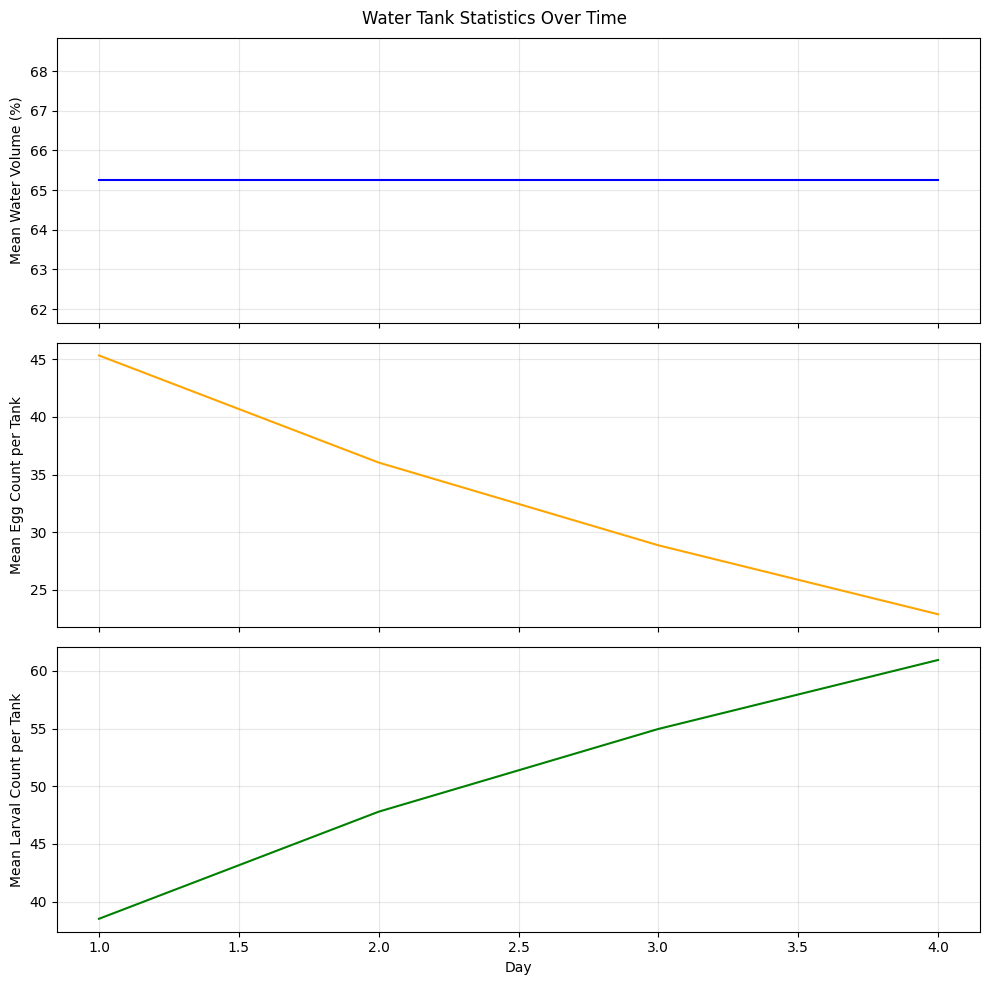

In [108]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(daily_inert['Day'], daily_inert['MeanWaterVolume'], color='blue')
axes[0].set_ylabel('Mean Water Volume (%)'); axes[0].grid(True, alpha=0.3)
axes[1].plot(daily_inert['Day'], daily_inert['TotalEggs'] / daily_inert['TankCount'].clip(lower=1), color='orange')
axes[1].set_ylabel('Mean Egg Count per Tank'); axes[1].grid(True, alpha=0.3)
axes[2].plot(daily_inert['Day'], daily_inert['TotalLarvae'] / daily_inert['TankCount'].clip(lower=1), color='green')
axes[2].set_ylabel('Mean Larval Count per Tank'); axes[2].set_xlabel('Day'); axes[2].grid(True, alpha=0.3)
plt.suptitle('Water Tank Statistics Over Time')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tank_stats.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Environmental Correlation

Plots daily average temperature and precipitation, and computes Pearson correlation with adult mosquito count.

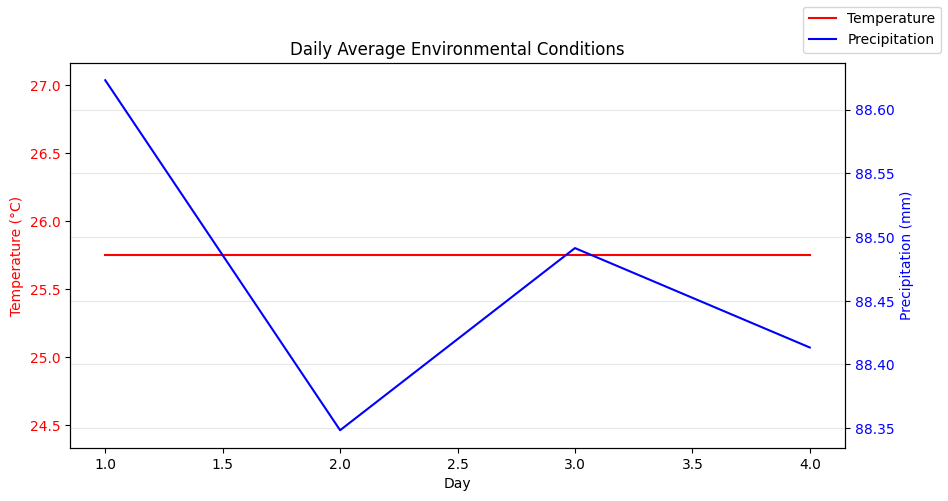

Correlation adult count vs Temperature: r=nan (p=nan)
Correlation adult count vs Precipitation: r=0.666 (p=3.341e-01)


In [109]:
if len(ENV_VARS) == 1:
    col, disp, unit, _, _ = ENV_VARS[0]
    mean_col = f'Mean{disp}'
    plt.figure(figsize=(10,5))
    plt.plot(daily_living['Day'], daily_living[mean_col], color='red')
    plt.ylabel(f'{disp} ({unit})', color='red')
    plt.xlabel('Day'); plt.title(f'Daily Average {disp}'); plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()
else:
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.set_xlabel('Day')
    axes = [ax1]; colors = ['red','blue','green','orange','purple']
    for i, (col, disp, unit, _, _) in enumerate(ENV_VARS):
        mean_col = f'Mean{disp}'
        if i == 0:
            ax = ax1
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
        else:
            ax = ax1.twinx()
            ax.set_ylabel(f'{disp} ({unit})', color=colors[i]); ax.tick_params(axis='y', labelcolor=colors[i])
            axes.append(ax)
        ax.plot(daily_living['Day'], daily_living[mean_col], color=colors[i], label=disp)
    fig.legend(loc='upper right')
    plt.title('Daily Average Environmental Conditions')
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight'); plt.show()

adult_series = daily_living['AdultCount'].values
for col, disp, unit, _, _ in ENV_VARS:
    mean_col = f'Mean{disp}'
    if mean_col in daily_living.columns:
        var_series = daily_living[mean_col].values
        corr, p = pearsonr(adult_series, var_series)
        print(f"Correlation adult count vs {disp}: r={corr:.3f} (p={p:.3e})")

## 5. Suitability Maps & GeoTIFF Export

Generates kernel density estimation (KDE) for adult mosquito distribution and rasterises tank loads to produce breeding site potential maps. Exports both as GeoTIFF.

Adult points collected: 116358
Using last tick 200 for tank load.
Tank load data collected: 10000 tanks
Adult suitability raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/adult_suitability.tif


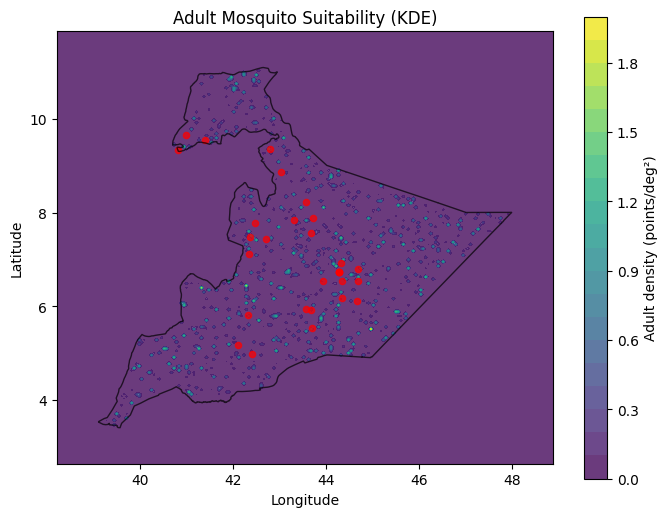

Breeding site potential raster saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/breeding_site_potential.tif


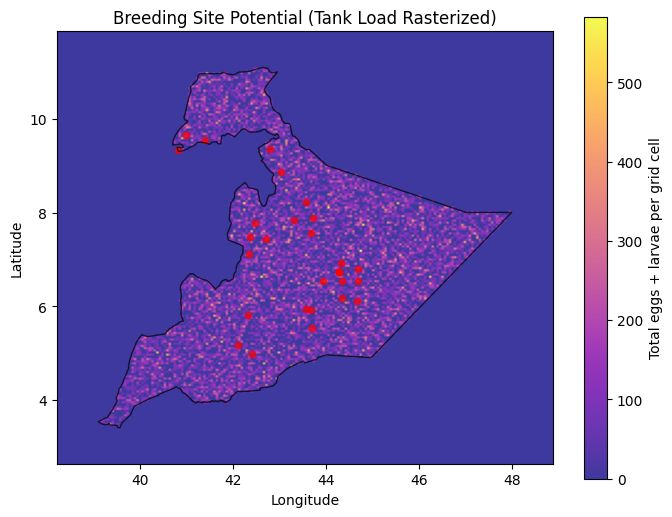

In [110]:
def accumulate_points(filepath, agent_type, stage=None, max_points=None):
    usecols = ['TickCount', 'AgentType', 'X', 'Y', 'Stage']
    all_points = []
    total = 0
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['AgentType'] == agent_type)
        if stage is not None:
            mask = mask & (chunk['Stage'] == stage)
        sub = chunk.loc[mask, ['X', 'Y']]
        if not sub.empty:
            all_points.append(sub)
            total += len(sub)
            if max_points and total >= max_points:
                break
    if not all_points:
        return pd.DataFrame()
    result = pd.concat(all_points, ignore_index=True)
    if max_points and len(result) > max_points:
        result = result.sample(n=max_points, random_state=42)
    return result

MAX_KDE_POINTS = 200000
adult_points = accumulate_points(INPUT_FILE, 'LivingAgent', stage='ADULT', max_points=MAX_KDE_POINTS)
print(f"Adult points collected: {len(adult_points)}")

# Tank load for the last tick
last_tick = None
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType'], low_memory=False):
    last_tick = chunk['TickCount'].max()
    break
print(f"Using last tick {last_tick} for tank load.")
tanks_load = []
for chunk in pd.read_csv(INPUT_FILE, chunksize=CHUNKSIZE, usecols=['TickCount', 'AgentType', 'X', 'Y', 'EggCount', 'LarvaCount'], low_memory=False):
    mask = (chunk['TickCount'] == last_tick) & (chunk['AgentType'] == 'InertAgent')
    sub = chunk.loc[mask, ['X', 'Y', 'EggCount', 'LarvaCount']]
    if not sub.empty:
        tanks_load.append(sub)
        if sum(len(df) for df in tanks_load) > 200000:
            break
if tanks_load:
    tanks_load_df = pd.concat(tanks_load, ignore_index=True)
    tanks_load_df['Load'] = tanks_load_df['EggCount'] + tanks_load_df['LarvaCount']
else:
    tanks_load_df = pd.DataFrame()
print(f"Tank load data collected: {len(tanks_load_df)} tanks")

def create_kde_suitability(points, bandwidth_deg=KDE_BANDWIDTH_DEG, grid_res=KDE_GRID_RES):
    if len(points) < 10:
        return None, None, None, None
    if study_area is not None:
        bounds = study_area.total_bounds
        xmin, ymin, xmax, ymax = bounds
    else:
        xmin, xmax = points['X'].min(), points['X'].max()
        ymin, ymax = points['Y'].min(), points['Y'].max()
    dx = (xmax - xmin) * 0.1
    dy = (ymax - ymin) * 0.1
    xmin -= dx; xmax += dx; ymin -= dy; ymax += dy
    x = np.linspace(xmin, xmax, grid_res)
    y = np.linspace(ymin, ymax, grid_res)
    xx, yy = np.meshgrid(x, y)
    grid = np.vstack([xx.ravel(), yy.ravel()]).T
    kde = KernelDensity(bandwidth=bandwidth_deg, metric='euclidean')
    kde.fit(points[['X','Y']].values)
    log_dens = kde.score_samples(grid)
    dens = np.exp(log_dens).reshape(xx.shape)
    return xx, yy, dens, (xmin, xmax, ymin, ymax)

adult_kde = create_kde_suitability(adult_points)

if adult_kde[0] is not None:
    xx, yy, dens, (xmin, xmax, ymin, ymax) = adult_kde
    if EXPORT_RASTERS:
        transform = from_origin(xmin, ymax, (xmax-xmin)/dens.shape[1], (ymax-ymin)/dens.shape[0])
        adult_tif = os.path.join(OUTPUT_DIR, 'adult_suitability.tif')
        with rasterio.open(adult_tif, 'w', driver='GTiff', height=dens.shape[0], width=dens.shape[1],
                           count=1, dtype=dens.dtype, crs='EPSG:4326', transform=transform) as dst:
            dst.write(dens, 1)
        print(f"Adult suitability raster saved to {adult_tif}")
    
    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, dens, levels=20, cmap='viridis', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.7)
    if occurrences is not None:
        occurrences.plot(ax=plt.gca(), color='red', marker='o', markersize=20, alpha=0.7, label='Occurrences')
    plt.colorbar(label='Adult density (points/deg²)')
    plt.title('Adult Mosquito Suitability (KDE)')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/adult_suitability.png', dpi=300, bbox_inches='tight')
    plt.show()

if not tanks_load_df.empty and EXPORT_RASTERS:
    if adult_kde[0] is not None:
        _, _, _, (xmin, xmax, ymin, ymax) = adult_kde
    elif study_area is not None:
        bounds = study_area.total_bounds
        xmin, ymin, xmax, ymax = bounds
        dx = (xmax - xmin) * 0.1
        dy = (ymax - ymin) * 0.1
        xmin -= dx; xmax += dx; ymin -= dy; ymax += dy
    else:
        xmin, xmax = tanks_load_df['X'].min(), tanks_load_df['X'].max()
        ymin, ymax = tanks_load_df['Y'].min(), tanks_load_df['Y'].max()
        dx = (xmax - xmin) * 0.1
        dy = (ymax - ymin) * 0.1
        xmin -= dx; xmax += dx; ymin -= dy; ymax += dy
    grid_res = KDE_GRID_RES
    x_edges = np.linspace(xmin, xmax, grid_res + 1)
    y_edges = np.linspace(ymin, ymax, grid_res + 1)
    col_idx = np.digitize(tanks_load_df['X'], x_edges) - 1
    row_idx = np.digitize(tanks_load_df['Y'], y_edges) - 1
    load_raster = np.zeros((grid_res, grid_res), dtype=np.float32)
    for r, c, load in zip(row_idx, col_idx, tanks_load_df['Load']):
        if 0 <= r < grid_res and 0 <= c < grid_res:
            load_raster[r, c] += load
    transform = from_origin(xmin, ymax, (xmax - xmin) / grid_res, (ymax - ymin) / grid_res)
    tank_tif = os.path.join(OUTPUT_DIR, 'breeding_site_potential.tif')
    with rasterio.open(tank_tif, 'w', driver='GTiff', height=grid_res, width=grid_res,
                       count=1, dtype=load_raster.dtype, crs='EPSG:4326', transform=transform) as dst:
        dst.write(load_raster, 1)
    print(f"Breeding site potential raster saved to {tank_tif}")

    plt.figure(figsize=(8,6))
    im = plt.imshow(load_raster, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='plasma', alpha=0.8)
    if study_area is not None:
        study_area.boundary.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.7)
    if occurrences is not None:
        occurrences.plot(ax=plt.gca(), color='red', marker='o', markersize=20, alpha=0.7, label='Occurrences')
    plt.colorbar(im, label='Total eggs + larvae per grid cell')
    plt.title('Breeding Site Potential (Tank Load Rasterized)')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.savefig(f'{OUTPUT_DIR}/breeding_site_potential.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No tank load data – cannot export breeding site raster.")

## 6. Validation against Real Occurrence Data (clipped to study area)

Computes the proportion of occurrence points falling into high‑suitability areas and the continuous Boyce index for presence‑only validation.

In [111]:
if occurrences is not None and adult_kde[0] is not None:
    xx, yy, dens, _ = adult_kde
    x_grid = xx[0,:]
    y_grid = yy[:,0]
    occ_coords = np.array([[geom.x, geom.y] for geom in occurrences.geometry])
    interp = RegularGridInterpolator((y_grid, x_grid), dens, bounds_error=False, fill_value=0)
    occ_dens = interp(occ_coords[:, [1,0]])
    threshold = np.percentile(dens[dens>0], 80)
    high_suit = occ_dens >= threshold
    accuracy = np.mean(high_suit) * 100
    print(f"Proportion of occurrence points in top 20% adult suitability: {accuracy:.1f}%")
    
    # Continuous Boyce Index
    def continuous_boyce_index(suit_raster, x_grid, y_grid, occ_coords, n_bins=20):
        suit_flat = suit_raster.ravel()
        suit_min, suit_max = np.percentile(suit_flat[suit_flat>0], [1,99])
        if suit_min == suit_max:
            suit_min = suit_flat.min()
            suit_max = suit_flat.max()
        bins = np.linspace(suit_min, suit_max, n_bins+1)
        # Expected: area proportion
        flat = suit_raster.ravel()
        area_counts = np.histogram(flat, bins=bins)[0]
        expected = area_counts / area_counts.sum()
        # Observed: occurrence proportion
        occ_vals = interp(occ_coords[:, [1,0]])
        obs_counts = np.histogram(occ_vals, bins=bins)[0]
        observed = obs_counts / obs_counts.sum()
        valid = expected > 0
        if not valid.any():
            return np.nan
        return spearmanr(observed[valid], expected[valid])[0]

    boyce = continuous_boyce_index(dens, x_grid, y_grid, occ_coords)
    print(f"Continuous Boyce Index = {boyce:.3f}")
else:
    print("Occurrence data or suitability KDE missing – cannot compute validation.")

Proportion of occurrence points in top 20% adult suitability: 56.7%
Continuous Boyce Index = 0.764


## 7. Export Tidy Data

Saves daily summaries and a sample of raw data for further analysis.

In [112]:
daily_summary = pd.merge(daily_living, daily_inert, on='Day', how='outer')
daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)
sample_df = pd.read_csv(INPUT_FILE, nrows=10000)
sample_df.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)
print(f"Summaries saved to {OUTPUT_DIR}/")
print("Files: daily_summary.csv, living_sample.csv")

Summaries saved to /mnt/monadworld/projects/phd/article_manuscripts/new/figs/somali/
Files: daily_summary.csv, living_sample.csv


In [113]:
print("Analysis complete. All figures and rasters saved.")

Analysis complete. All figures and rasters saved.
